# Определение состояния для записей 7 и 9 по альфа-пику

Этот ноутбук:
- загружает EDF-файлы `7` и `9`;
- строит спектры мощности для каналов `O1` и `O2`;
- оценивает наличие альфа-пика в диапазоне 8-13 Гц;
- помогает определить, какая запись соответствует состоянию с закрытыми глазами.


In [8]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch


In [9]:
file_7 = "7 2026.01.24-16.53.06.041.edf"
file_9 = "9 2026.01.24-17.05.59.615.edf"

raw_7 = mne.io.read_raw_edf(file_7, preload=True, verbose="ERROR")
raw_9 = mne.io.read_raw_edf(file_9, preload=True, verbose="ERROR")

print(raw_7.ch_names)
print(raw_9.ch_names)


['O1', 'T3', 'Fp1', 'Fp2', 'T4', 'O2']
['O1', 'T3', 'Fp1', 'Fp2', 'T4', 'O2']


In [10]:
channels_of_interest = ["O1", "O2"]
alpha_band = (8, 13)
beta_band = (13, 30)


In [11]:
def get_channel_psd(raw, ch_name):
    data = raw.copy().pick([ch_name]).get_data()[0]
    sfreq = raw.info["sfreq"]
    freqs, psd = welch(data, fs=sfreq, nperseg=min(len(data), int(sfreq * 4)))
    return freqs, psd


In [12]:
def band_power(freqs, psd, fmin, fmax):
    mask = (freqs >= fmin) & (freqs <= fmax)
    return np.trapezoid(psd[mask], freqs[mask])


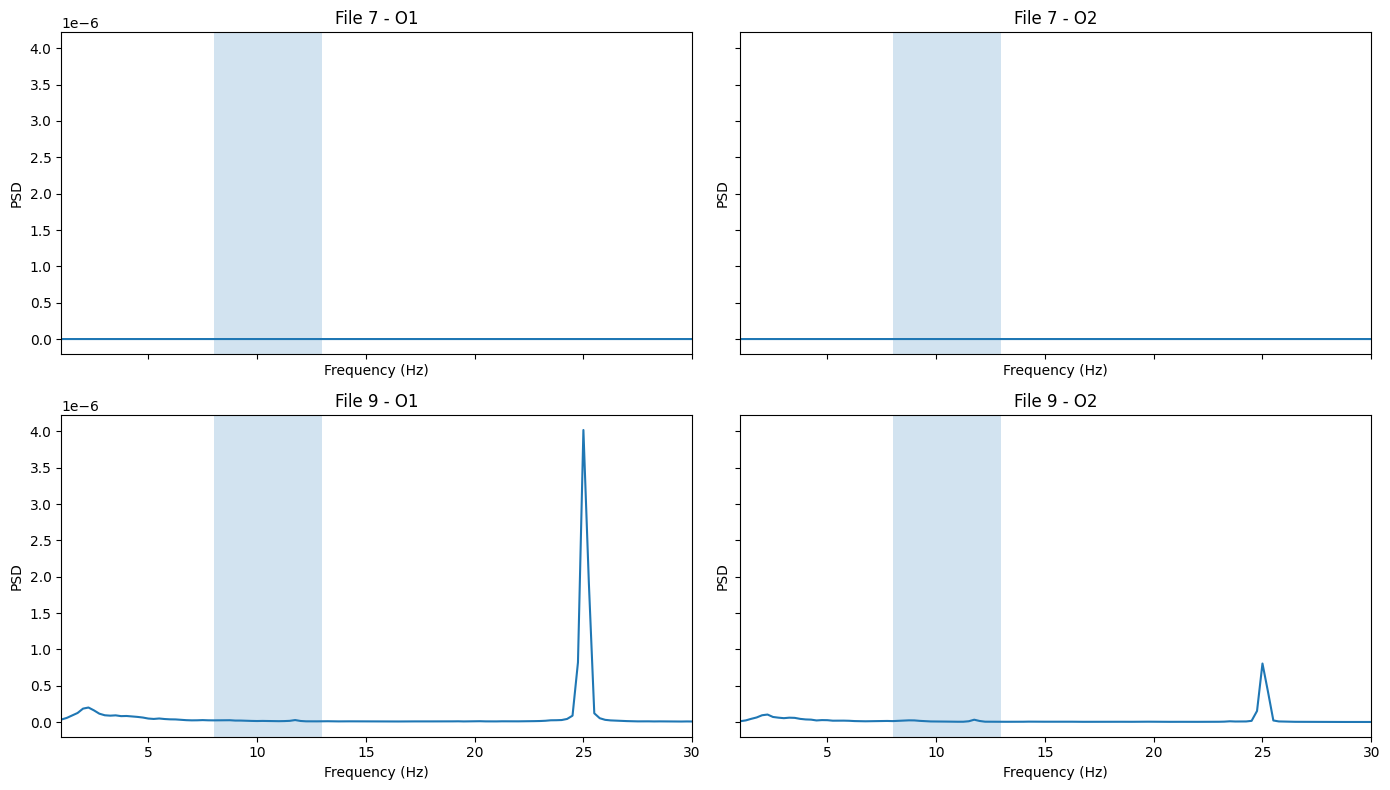

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)

for row, (label, raw_obj) in enumerate([("File 7", raw_7), ("File 9", raw_9)]):
    for col, ch_name in enumerate(channels_of_interest):
        freqs, psd = get_channel_psd(raw_obj, ch_name)

        axes[row, col].plot(freqs, psd, linewidth=1.5)
        axes[row, col].axvspan(alpha_band[0], alpha_band[1], alpha=0.2)
        axes[row, col].set_xlim(1, 30)
        axes[row, col].set_title(f"{label} - {ch_name}")
        axes[row, col].set_xlabel("Frequency (Hz)")
        axes[row, col].set_ylabel("PSD")

plt.tight_layout()
plt.show()


In [14]:
results = []

for label, raw_obj in [("File 7", raw_7), ("File 9", raw_9)]:
    row = {"file": label}
    alpha_beta_ratios = []

    for ch_name in channels_of_interest:
        freqs, psd = get_channel_psd(raw_obj, ch_name)

        alpha_power = band_power(freqs, psd, alpha_band[0], alpha_band[1])
        beta_power = band_power(freqs, psd, beta_band[0], beta_band[1])
        alpha_beta_ratio = alpha_power / beta_power if beta_power > 0 else np.nan

        row[f"{ch_name}_alpha_power"] = alpha_power
        row[f"{ch_name}_beta_power"] = beta_power
        row[f"{ch_name}_alpha_beta_ratio"] = alpha_beta_ratio

        alpha_beta_ratios.append(alpha_beta_ratio)

    row["mean_alpha_beta_ratio"] = np.nanmean(alpha_beta_ratios)
    results.append(row)

results


[{'file': 'File 7',
  'O1_alpha_power': np.float64(6.173075631635113e-12),
  'O1_beta_power': np.float64(8.412736508424679e-12),
  'O1_alpha_beta_ratio': np.float64(0.7337773654806939),
  'O2_alpha_power': np.float64(1.2751128055625532e-11),
  'O2_beta_power': np.float64(1.5155923985301293e-11),
  'O2_alpha_beta_ratio': np.float64(0.8413296390237897),
  'mean_alpha_beta_ratio': np.float64(0.7875535022522417)},
 {'file': 'File 9',
  'O1_alpha_power': np.float64(8.837665268211024e-08),
  'O1_beta_power': np.float64(1.953632203214151e-06),
  'O1_alpha_beta_ratio': np.float64(0.045237098639504085),
  'O2_alpha_power': np.float64(6.288906224785844e-08),
  'O2_beta_power': np.float64(4.316880134119644e-07),
  'O2_alpha_beta_ratio': np.float64(0.14568174305049036),
  'mean_alpha_beta_ratio': np.float64(0.09545942084499723)}]

In [15]:
for row in results:
    print(row["file"])
    print("  O1 alpha/beta:", round(row["O1_alpha_beta_ratio"], 4))
    print("  O2 alpha/beta:", round(row["O2_alpha_beta_ratio"], 4))
    print("  Mean alpha/beta:", round(row["mean_alpha_beta_ratio"], 4))


File 7
  O1 alpha/beta: 0.7338
  O2 alpha/beta: 0.8413
  Mean alpha/beta: 0.7876
File 9
  O1 alpha/beta: 0.0452
  O2 alpha/beta: 0.1457
  Mean alpha/beta: 0.0955


In [16]:
best_candidate = max(results, key=lambda x: x["mean_alpha_beta_ratio"])

print("Более вероятно, что закрытые глаза:")
print(best_candidate["file"])


Более вероятно, что закрытые глаза:
File 7
